**RANDOM IMPUTATION**
Choses random number from the columns. Random doesn't mean complete random. It basically means the random values among the given data. This preserves normality of the data and varience

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('../../../EDA/data/train.csv', usecols=['Age', 'Fare', 'Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [9]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [11]:
X_train.tail()

,Age,Fare,Age_imputed
106,21.0,7.6500,21.0
270,NaN,31.0000,NaN
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0
102,21.0,77.2875,21.0


In [ ]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


ValueError: cannot set using a list-like indexer with a different length than the value

In [20]:
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [21]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([62.  , 53.  , 19.  , 32.  , 37.  , 22.  , 34.  , 40.5 , 32.  ,
       42.  , 25.  , 61.  , 44.  , 43.  , 48.  , 24.  , 57.  , 23.  ,
       43.  , 19.  , 26.  , 35.  , 40.  , 56.  , 39.  , 17.  , 39.  ,
       31.  , 30.  , 17.  , 34.  , 45.  , 47.  , 35.  , 19.  , 22.  ,
       22.  , 41.  , 36.  , 30.  , 19.  , 32.  , 16.  , 25.  , 28.  ,
       18.  , 20.  , 39.  , 18.  , 32.  , 36.5 , 25.  ,  2.  , 30.  ,
       31.  , 30.  ,  6.  , 18.  , 30.  , 15.  , 32.  , 24.  , 28.  ,
       47.  , 28.  ,  2.  , 30.  ,  0.92, 38.  , 51.  , 29.  ,  8.  ,
       36.  , 23.  , 29.  ,  4.  , 41.  , 24.  , 18.  , 52.  ,  9.  ,
        4.  , 20.  , 20.  ,  4.  , 34.  , 14.  , 30.  , 34.  , 28.  ,
       19.  , 60.  , 38.  ,  2.  , 44.  , 24.  , 27.  , 31.  , 23.  ,
        1.  , 27.  , 14.  , 25.  , 35.  ,  4.  , 28.  , 49.  , 42.  ,
        5.  , 22.  , 17.  , 19.  ,  1.  , 29.  , 18.  , 54.  , 21.  ,
       36.  , 22.  ,  1.  , 22.  , 60.  , 25.  , 26.  , 62.  , 30.  ,
       50.  ,  8.  ,

In [23]:
X_train.isnull().sum()

Age            140
Fare             0
Age_imputed      0
dtype: int64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25776\3773879143.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train['Age'], label='Original Age', shade=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_25776\3773879143.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train['Age_imputed'], label='Imputed Age', shade=False, color='red')


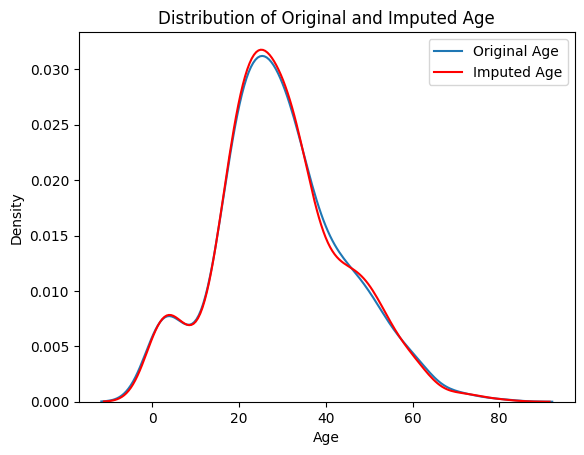

In [30]:
sns.kdeplot(X_train['Age'], label='Original Age', shade=False)
sns.kdeplot(X_train['Age_imputed'], label='Imputed Age', shade=False, color='red')
plt.legend()
plt.title('Distribution of Original and Imputed Age')
plt.show()

In [31]:
print("Original Age Mean:", X_train['Age'].var())
print("Imputed Age Mean:", X_train['Age_imputed'].var())

Original Age Mean: 210.2517072477435
Imputed Age Mean: 207.40516340156293


In [32]:
X_train.cov()

,Age,Fare,Age_imputed
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,61.066261
Age_imputed,210.251707,61.066261,207.405163


<Axes: >

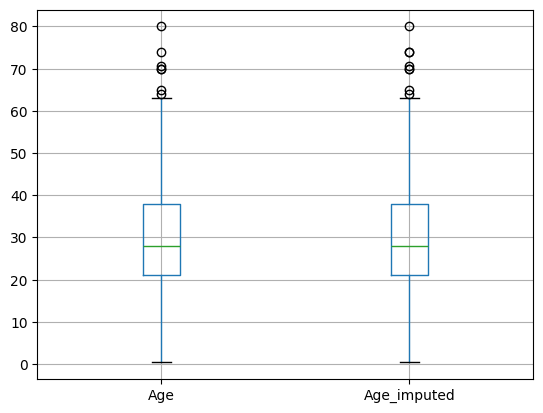

In [33]:
X_train.drop('Fare', axis=1).boxplot()

In [35]:
#For categorical
data = pd.read_csv('../../../EDA/data/house.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [36]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [38]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [39]:
X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [43]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values

In [44]:
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [45]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [46]:
temp

,original,imputed
TA,0.951087,0.950342
Fa,0.032609,0.032534
Gd,0.011775,0.012842
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [47]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.491143,0.645342
TA,0.405797,0.533109
Fa,0.043478,0.053872
Ex,0.033816,0.046016
Po,0.025765,0.032548


In [49]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.show()

KeyError: 'SalePrice'